In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pulsefig as pf
from pulsefig import Element
from pulsefig import Line, LineEnsemble
import numpy as np


In [3]:
print(pf.update_style("contour"))
# print(pf.update_style("fill"))
# print(pf.update_style("fill"))

{'color': '#0050A0', 'fontsize': StyleLink(legend.fontsize), 'annotation.color': StyleLink(color), 'text.fontsize': StyleLink(fontsize), 'text.color': '#000', 'level.line.color': StyleLink(color), 'level.text.fontsize': StyleLink(fontsize), 'level.textoffset': 1.0, 'fill.color': StyleLink(color), 'contour.color': StyleLink(color), 'fill': False, 'contour': True}


Line 0 : Qubit with 1 elements 
	Element : None (0.1, 1.1)

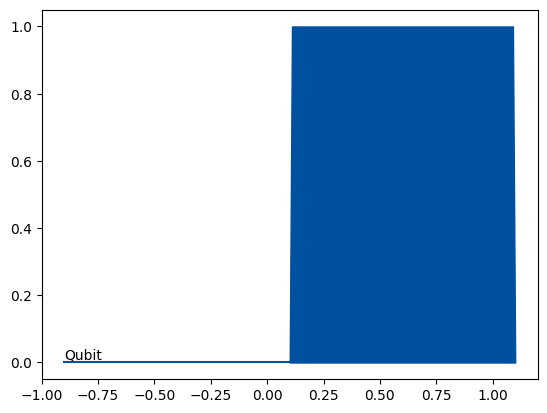

In [3]:
# .update_style(0, fill_alpha=0.1, contour=True, line_alpha=1)

fig, ax = plt.subplots()

qubit_line = pf.Line("Qubit").attach_elements(pf.Element(0, duration=1, delay=0.1))

qubit_line.draw(ax)

LineEnsemble with 2 lines :
	Line : Membrane
	Line : Qubit

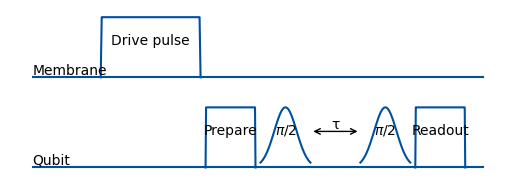

In [9]:
fig, ax = plt.subplots()
pf.update_style("contour")
# pf.update_style("contour", contour_lw=2, level_textoffset=2, text_fontsize=8)

membrane_line = pf.Line("Membrane").attach_elements(
    membrane_drive_elm := pf.Element(0, duration=2).set_title("Drive pulse"),
)
qubit_line = pf.Line("Qubit").attach_elements(
    qubit_prepare_elm := pf.Element(
        membrane_drive_elm, duration=1, delay=0.1
    ).set_title("Prepare"),
    pi_pulse1 := pf.Element.Gaussian(
        qubit_prepare_elm, duration=1, delay=0.1
    ).set_title("$π/2$"),
    pi_pulse2 := pf.Element.Gaussian(pi_pulse1, duration=1, delay=1).set_title("$π/2$"),
    readout_elm := pf.Element(pi_pulse2, duration=1, delay=0.1).set_title("Readout"),
)

pi_pulse1.annotation_to(pi_pulse2, "τ")
(membrane_line + qubit_line).set(text_offset=2).draw(ax).config_ax(
    ax,
)

In [6]:
pf.reset_style()

{'color': '#0050A0',
 'fontsize': StyleLink(legend.fontsize),
 'annotation.color': StyleLink(color),
 'text.fontsize': 4,
 'text.color': '#000',
 'level.line.color': StyleLink(color),
 'level.text.fontsize': StyleLink(fontsize),
 'level.textoffset': 2,
 'fill.color': StyleLink(color),
 'contour.color': StyleLink(color),
 'fill': False,
 'contour': True,
 'contour.lw': 2}